Loading noisy image...
No clean GT found.
No SIM GT found.

Starting Denoising (aSeqDIP)...


aSeqDIP Denoising: 100%|██████████| 2000/2000 [44:24<00:00,  1.33s/epoch]


Denoising completed.

Starting Deconvolution (RLG-DIP)...


RLG-DIP Deconv: 100%|██████████| 2000/2000 [57:24<00:00,  1.72s/epoch, loss=0.00241] 


Deconvolution completed.


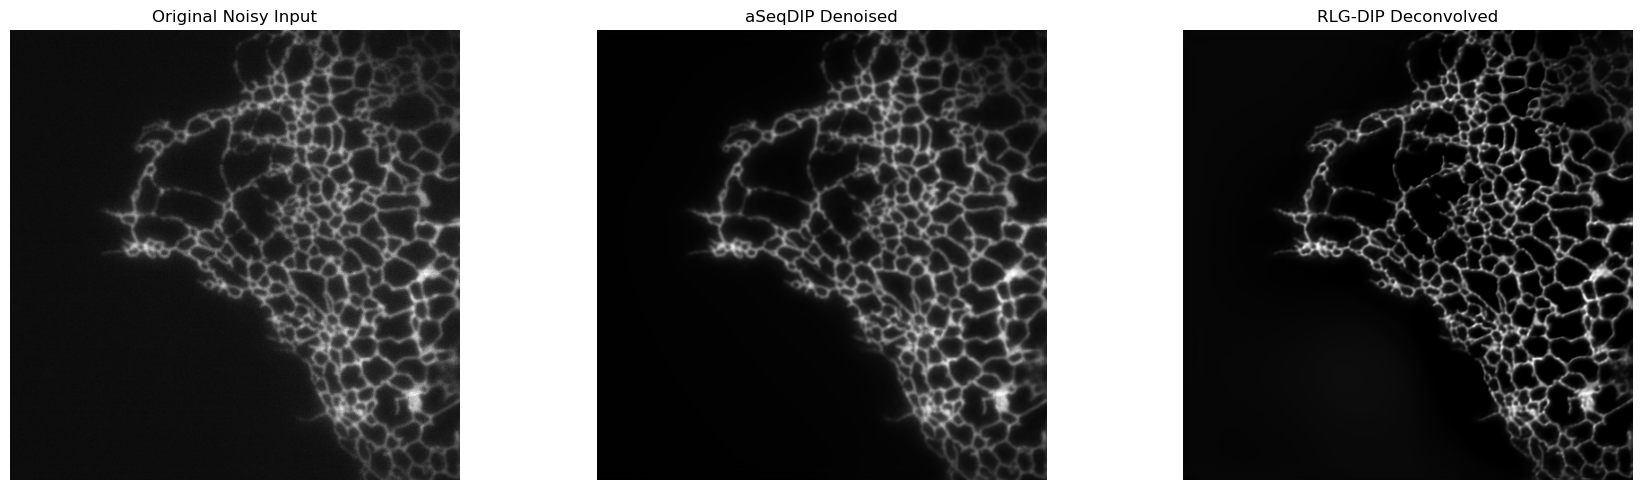


Results saved: 'denoised_result.tiff' and 'deconvolved_result.tiff'


In [4]:
# -*- coding: utf-8 -*-
import os
import sys
sys.path.append('.')
sys.path.append('./stage-wise')

import numpy as np
import matplotlib.pyplot as plt

from Tools import load_16bit_tiff, save_16bit_tiff
from aSeqDIPdenoise import aSeqDIP_denoise
from RLGDIPdeconv import RLG_dip_deconv  

# ==================== Configuration ====================
base_path = r'./image/SDIP'
noisy_fname = os.path.join(base_path, 'ER10-raw.tiff')
clean_gt_fname = None   # optional, set to path if available
# clean_gt_fname = os.path.join(base_path, 'ER10-cleargt.tiff')
sim_gt_fname   = None   # optional, set to path if available
# sim_gt_fname  = os.path.join(base_path, 'ER10-SIMgt.tiff')

# Denoising parameters (weights default 1)
denoise_epochs = 2000
denoise_inner = 10
denoise_lr = 1e-4
denoise_data_weight = 1.0
denoise_reg_weight = 1.0

# Deconvolution parameters (optical)
NA = 1.3
wavelength = 488
sizePixel = 6.26
MA = 100

# Deconvolution training (weights default 1)
deconv_epochs = 2000
deconv_inner = 10
deconv_data_weight = 1.0
deconv_reg_weight = 1.0
deconv_rl_weight = 1.0
deconv_lr = 1e-4
rl_iters = 10
bg_option = 1       # 1-6, 0 to skip

# ==================== Load images ====================
print("Loading noisy image...")
img_raw = load_16bit_tiff(noisy_fname)   # (H,W) in [0,1]

has_clean_gt = (clean_gt_fname is not None) and os.path.exists(clean_gt_fname)
has_sim_gt = (sim_gt_fname is not None) and os.path.exists(sim_gt_fname)

if has_clean_gt:
    clean_gt = load_16bit_tiff(clean_gt_fname)
    if len(clean_gt.shape) == 3:
        clean_gt = clean_gt[0] if clean_gt.shape[0] == 1 else clean_gt
    print("Clean GT loaded (will be used for selecting best denoising result).")
else:
    clean_gt = None
    print("No clean GT found.")

if has_sim_gt:
    sim_gt = load_16bit_tiff(sim_gt_fname)
    if len(sim_gt.shape) == 3:
        sim_gt = sim_gt[0] if sim_gt.shape[0] == 1 else sim_gt
    print("SIM GT loaded (for deconvolution).")
else:
    sim_gt = None
    print("No SIM GT found.")

# ==================== Stage 1: Denoising ====================
print("\nStarting Denoising (aSeqDIP)...")
denoised_img = aSeqDIP_denoise(
    img_raw,
    num_epochs=denoise_epochs,
    inner_iterations=denoise_inner,
    learning_rate=denoise_lr,
    data_weight=denoise_data_weight,
    reg_weight=denoise_reg_weight,
    has_gt=has_clean_gt,
    gt_np=clean_gt,
    verbose=True
)
print("Denoising completed.")

# ==================== Stage 2: Deconvolution ====================
print("\nStarting Deconvolution (RLG-DIP)...")
deconvolved_img = RLG_dip_deconv(
    denoised_img,
    NA=NA, wavelength=wavelength, sizePixel=sizePixel, MA=MA,
    num_epochs=deconv_epochs, inner_iterations=deconv_inner,
    data_weight=deconv_data_weight,
    reg_weight=deconv_reg_weight,
    rl_weight=deconv_rl_weight,
    learning_rate=deconv_lr,
    rl_iterations=rl_iters,
    background_option=bg_option,
    verbose=True
)
print("Deconvolution completed.")

# ==================== Display three images ====================
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_raw, cmap='gray')
plt.axis('off')
plt.title('Original Noisy Input')

plt.subplot(1, 3, 2)
plt.imshow(denoised_img, cmap='gray')
plt.axis('off')
plt.title('aSeqDIP Denoised')

plt.subplot(1, 3, 3)
plt.imshow(deconvolved_img, cmap='gray')
plt.axis('off')
plt.title('RLG-DIP Deconvolved')

plt.tight_layout()
plt.show()

# ==================== Save results ====================
save_16bit_tiff(denoised_img, 'denoised_result.tiff')
save_16bit_tiff(deconvolved_img, 'deconvolved_result.tiff')
print("\nResults saved: 'denoised_result.tiff' and 'deconvolved_result.tiff'")